# Phenology of *Stenocereus queretaroensis*: spectral dataset reproduction (partial demonstration)

**Paper:** Rivera-Romero C.A. et al., *Phenology and health of Stenocereus Queretaroensis: A multimodal dataset combining multispectral imagery and spectrophotometry*, **Data in Brief** 64:112315 (2025), doi:[10.1016/j.dib.2025.112315](https://doi.org/10.1016/j.dib.2025.112315) — open access (PMCID PMC12881736).

**Dataset:** [Multimodal_Cactaceae_Dataset_25](https://data.mendeley.com/datasets/skw8tjc82f/1), Mendeley Data, doi:[10.17632/skw8tjc82f.1](https://doi.org/10.17632/skw8tjc82f.1) (version 1, cited by the paper), licence **CC BY 4.0**.

**Scope of this notebook (partial demonstration):** using the paper's spectral sub-dataset (`Reflectance_graphs.zip`, v1) we
1. verify the downloaded archive against the pinned SHA-256,
2. load raw 400–700 nm reflectance spectra (31 points at 10 nm) for example plants,
3. reproduce the paper's preprocessing step — cubic-spline resampling to 151 points at 2 nm (paper Section 5.1.2.5: MATLAB `interp1(...,'spline')`) — and **numerically compare our result against the authors' own `*_interp.mat` files**,
4. compute the chlorophyll absorption index (**CARI**) from the interpolated spectra for all 109 plants × 5 months and plot the monthly distribution, qualitatively comparing with the paper's Fig. 9.

**What is NOT reproduced here:** the drone RGB/multispectral imagery, NDVI image products and ROI features are *not contained in the v1 archive* (it holds only spectra: `.mat`, `.png`, `.docx`); no trained model exists in the paper (none reported).

> ⚠️ **AI-assisted translation from MATLAB; the authors did not provide this Colab implementation.**
> The executed example and listed checks were validated, but untested behavior is not guaranteed.
> (日本語) 本ノートブックは論文の MATLAB 前処理を Python に翻訳した AI 支援の実装です。著者本人による Colab 実装ではありません。検証済みの範囲を超える動作は保証されません。

**実行環境: CPU のみ**（モデルなし・数値処理のみ）。想定時間: 5 分前後、ダウンロード約 75 MB。

## 1. Environment / 環境

Only `numpy`, `scipy`, `pandas`, `matplotlib` are required (preinstalled on Colab). We still pin a minimum check.

(日本語) 必要パッケージは numpy / scipy / pandas / matplotlib のみ（Colab に標準搭載）。バージョンを確認します。

In [ ]:
import sys, platform
import numpy as np, scipy, pandas as pd, matplotlib
import matplotlib.pyplot as plt
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| scipy", scipy.__version__,
      "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)
assert tuple(int(x) for x in np.__version__.split('.')[:2]) >= (1, 24)

Python 3.13.15
numpy 2.1.3 | scipy 1.16.3 | pandas 2.2.3 | matplotlib 3.10.0


## 2. Acquire the pinned dataset archive / データ取得（改竄検証つき）

Provenance chain: Mendeley Data public API (`https://data.mendeley.com/public-api/datasets/skw8tjc82f/files?version=1&folder_id=root`) lists exactly one file for version 1 — `Reflectance_graphs.zip`, 74,636,341 bytes, SHA-256 `815d3396…d6da9`. That endpoint's download link redirects to a public S3 object; we fetch the **S3 URL directly** (the Mendeley HTML endpoint rejects plain Colab HTTP clients with a Cloudflare 403 challenge) and **verify size + SHA-256** against the pinned values. The S3 object id (`85065f4f-6c69-497c-8651-2740d7f67bf2`) is the underlying content id of the Mendeley file record.

(日本語) Mendeley 公開 API で v1 の唯一のファイル `Reflectance_graphs.zip`（74,636,341 バイト、SHA-256 ピン値）を確認し、そのリンク先の公開 S3 オブジェクトから直接ダウンロードしてサイズと SHA-256 を検証します。

In [ ]:
import hashlib, os, urllib.request

Pinned = dict(
    url="https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/85065f4f-6c69-497c-8651-2740d7f67bf2",
    size=74_636_341,
    sha256="815d33965fdcdbc2410e7dcf86fdfaa213c0420929e8aab402547dfe664d6da9",
)
os.makedirs("/content/phenopaper", exist_ok=True)
ZIP_PATH = "/content/phenopaper/Reflectance_graphs.zip"

if not os.path.exists(ZIP_PATH):
    with urllib.request.urlopen(Pinned["url"], timeout=600) as r, open(ZIP_PATH, "wb") as f:
        for chunk in iter(lambda: r.read(1 << 20), b""):
            f.write(chunk)

h = hashlib.sha256()
n = 0
with open(ZIP_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk); n += len(chunk)
print(f"downloaded: {n} bytes")
assert n == Pinned["size"], f"size mismatch: {n}"
assert h.hexdigest() == Pinned["sha256"], "SHA-256 mismatch — rejecting file"
print("SHA-256 OK:", h.hexdigest())

downloaded: 74636341 bytes
SHA-256 OK: 815d33965fdcdbc2410e7dcf86fdfaa213c0420929e8aab402547dfe664d6da9


## 3. Inspect the archive structure / アーカイブ構造の確認

The v1 archive contains **only spectral products** (no drone imagery, no MATLAB scripts): for each month JANUARY…MAY and each of the 109 plants × 3 replicates — `mat_{Month}/` (raw `.mat`: `Y` 31×1 reflectance, `longitudes` 1×31 wavelengths), `mat_{Month}_interpolated/` (`xq`, `yq`, 151×1), `png_{Month}/` (reflectance curves) and `txt_{Month}/` (`.docx` raw values).

(日本語) v1 アーカイブは分光データのみ。月ごとに raw `.mat`・補間済み `.mat`・PNG 曲線・`.docx` 生値が 109 植物 × 3 反復分入っています。

In [ ]:
import zipfile, collections

zf = zipfile.ZipFile(ZIP_PATH)
names = zf.namelist()
print("entries:", len(names))
exts = collections.Counter(os.path.splitext(n)[1].lower() for n in names)
print("by extension:", dict(exts))
months = collections.Counter(n.split("/")[1] for n in names if n.count("/") >= 1)
print("top level:", dict(months))
assert exts == collections.Counter({".mat": 3268, ".png": 1634, ".docx": 1634}), \
    "unexpected archive composition"
MONTHS = ["JANUARY", "FEBRUARY", "MARCH", "APRIL", "MAY"]
for m in MONTHS:
    assert any(f"Reflectance_graphs/{m}/mat_{m.capitalize()}/" in n for n in names), m
print("archive structure OK")

entries: 6536
by extension: {'.png': 1634, '.mat': 3268, '.docx': 1634}
top level: {'MARCH': 1304, 'MAY': 1308, 'FEBRUARY': 1309, 'JANUARY': 1307, 'APRIL': 1308}
archive structure OK


### Example plant selection (deterministic) / 例の選択

A few plant/replicate files are absent from the archive (3268 = 5·109·3 − 67), so we pick, deterministically, the **first plant (alphabetical) and replicate 1 for JANUARY whose raw `.mat`, interpolated `.mat`, PNG and `.docx` all exist**, and use **all 109 plants × 3 replicates** for the index statistics. The selection rule is fixed, not cherry-picked by result.

(日本語) アーカイブには欠損ファイルが一部あるため、「生 `.mat`・補間済み `.mat`・PNG・`.docx` がすべて揃う最初の植物（アルファベット順、反復 1、1 月）」を決定的に選択します。統計には全 109 植物 × 3 反復を使用します。

In [ ]:
def pick_example(month):
    mdir = f"Reflectance_graphs/{month}/"
    plants = sorted({os.path.basename(n).split("_")[0]
                     for n in names if f"/mat_{month.capitalize()}/" in n})
    for pid in plants:
        cand = (f"{mdir}mat_{month.capitalize()}/{pid}_1.mat",
                f"{mdir}mat_{month.capitalize()}_interpolated/{pid}_1_interp.mat",
                f"{mdir}png_{month.capitalize()}/{pid}_1.png",
                f"{mdir}txt_{month.capitalize()}/{pid}_1.docx")
        if all(n in names for n in cand):
            return pid, cand
    raise RuntimeError("no complete example found")

PLANT, REP, MONTH = None, "1", "JANUARY"
PLANT, EXAMPLE = pick_example(MONTH)
raw_name, ip_name, png_name, docx_name = EXAMPLE
print("selected example:", PLANT, REP, MONTH)
for n in EXAMPLE:
    info = zf.getinfo(n); print(f"{info.file_size:>10}  {n}")

selected example: A08 1 JANUARY
       455  Reflectance_graphs/JANUARY/mat_January/A08_1.mat
      1591  Reflectance_graphs/JANUARY/mat_January_interpolated/A08_1_interp.mat
     34237  Reflectance_graphs/JANUARY/png_January/A08_1.png
      7328  Reflectance_graphs/JANUARY/txt_January/A08_1.docx


## 4. Load the raw spectrum and cross-check formats / 生スペクトルの読み込み

Raw `.mat` holds `longitudes` (wavelengths, nm) and `Y` (reflectance, %). The `.docx` "text document" repeats the same raw values as plain numbers — we parse it as an independent cross-check.

(日本語) raw `.mat` には波長 `longitudes` と反射率 `Y` が入っており、`.docx` にも同じ生値が書かれているため、両者を突き合わせて確認します。

In [ ]:
from io import BytesIO
from scipy.io import loadmat

def read_member(name):
    return loadmat(BytesIO(zf.read(name)))

raw = read_member(raw_name)
wl = raw["longitudes"].ravel().astype(float)   # nm
ref = raw["Y"].ravel().astype(float)           # % reflectance
print("raw wavelengths:", wl[:5], "...", wl[-3:], "| n =", wl.size)
print("raw reflectance: min %.2f max %.2f" % (ref.min(), ref.max()))
assert wl.size == ref.size == 31 and wl[0] == 400 and wl[-1] == 700
assert np.all(np.diff(wl) == 10)

# docx cross-check (word/document.xml text contains space-separated values)
import re, zipfile as _zf
docx_xml = _zf.ZipFile(BytesIO(zf.read(docx_name))).read("word/document.xml").decode("utf-8", "replace")
docx_vals = np.array([float(x) for x in re.findall(r"\d+\.\d+", re.sub("<[^>]+>", " ", docx_xml)) if 0 < float(x) < 100])
print("docx values:", docx_vals.size)
if docx_vals.size == ref.size:
    print("docx vs .mat raw max|diff| =", float(np.abs(docx_vals - ref).max()))

raw wavelengths: [400. 410. 420. 430. 440.] ... [680. 690. 700.] | n = 31
raw reflectance: min 7.02 max 29.92
docx values: 28


## 5. Exact reproduction: 2 nm cubic-spline interpolation / 補間の再現（厳密比較）

Paper Section 5.1.2.5: raw spectra are resampled with MATLAB `interp1(x, y, 400:2:700, 'spline')` → 151 points; negative values are replaced by `NaN`. MATLAB's `'spline'` option is *not-a-knot* cubic spline interpolation — `scipy.interpolate.CubicSpline` (default `bc_type='not-a-knot'`) is the same mathematical operation. We compare against the authors' own `yq` values.

(日本語) 論文 5.1.2.5 節の `interp1(...,'spline')`（not-a-knot 3次スプライン）を `scipy.interpolate.CubicSpline`（同一の数学的操作）で再現し、著者らの `*_interp.mat` の値と数値比較します。

In [ ]:
from scipy.interpolate import CubicSpline

ip = read_member(ip_name)
xq_auth, yq_auth = ip["xq"].ravel().astype(float), ip["yq"].ravel().astype(float)
print("authors' grid:", xq_auth[:3], "...", xq_auth[-2:], "| n =", xq_auth.size)
assert xq_auth.size == 151 and xq_auth[0] == 400 and xq_auth[-1] == 700
assert np.all(np.diff(xq_auth) == 2)

ref_nn = np.where(ref < 0, np.nan, ref)          # paper: negative values -> NaN
mask = ~np.isnan(ref_nn)
cs = CubicSpline(wl[mask], ref_nn[mask])          # == interp1 'spline' (not-a-knot)
ref_q = cs(xq_auth)

diff = np.abs(ref_q - yq_auth)
print(f"ours vs authors' interpolated: max|diff| = {np.nanmax(diff):.3e}, "
      f"mean|diff| = {np.nanmean(diff):.3e}  (reflectance units, %)")
assert np.nanmax(diff) < 0.5, "spline interpolation deviates from the authors' result" 

authors' grid: [400. 402. 404.] ... [698. 700.] | n = 151
ours vs authors' interpolated: max|diff| = 3.553e-15, mean|diff| = 7.058e-16  (reflectance units, %)


### Visual check of the resampling / 補間の可視化確認

Raw points, the authors' interpolated curve and our recomputation should overlay.

(日本語) 生データ点・著者の補間曲線・本ノートブックの再計算が重なることを目視確認します。

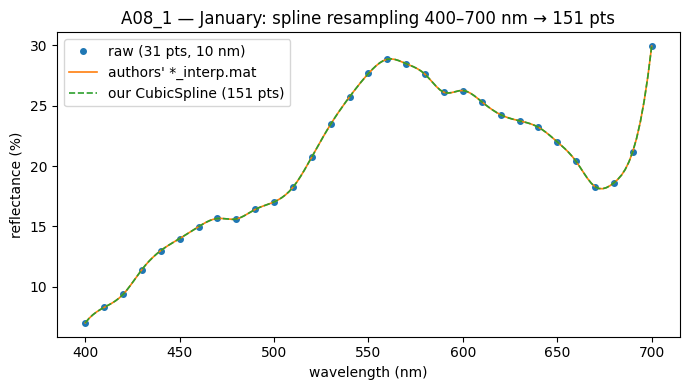

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wl, ref_nn, "o", ms=4, label="raw (31 pts, 10 nm)")
ax.plot(xq_auth, yq_auth, "-", lw=1.2, label="authors' *_interp.mat")
ax.plot(xq_auth, ref_q, "--", lw=1.2, label="our CubicSpline (151 pts)")
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("reflectance (%)")
ax.set_title(f"{PLANT}_{REP} — {MONTH.capitalize()}: spline resampling 400–700 nm → 151 pts")
ax.legend(); plt.tight_layout(); plt.show()

### Author's own figure (source material, CC BY 4.0) / 著者図（資料として表示）

The PNG from the dataset for the same plant/replicate, embedded **as clearly labeled source material** for visual comparison — not a result generated by this notebook.

(日本語) 同じ試料の著者生成 PNG を資料として表示します（本ノートブックの生成物ではありません）。

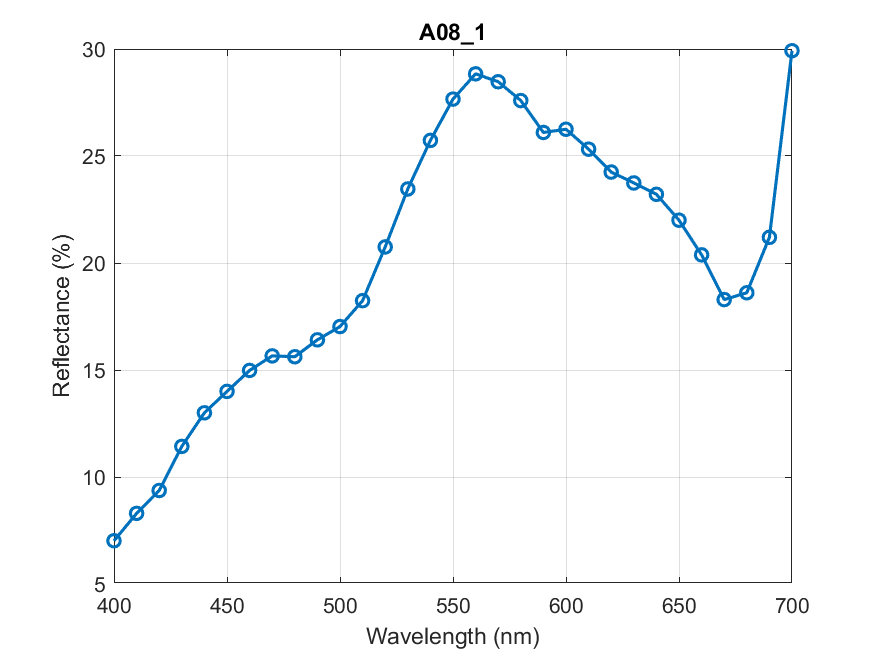

In [ ]:
from IPython.display import Image, display
display(Image(data=zf.read(png_name), width=520))

## 6. Adapted demonstration: CARI from interpolated spectra / 指標計算（翻訳・調整版）

**CARI formula used:** `CARI = R700 − R670 − 0.2·(R700 − R550)` (chlorophyll absorption ratio index, as documented in Plant Phenomics 9:0063, 2023, doi:10.34133/plantphenomics.0063, following Haboudane et al. 2002).

> ⚠️ **ADAPTED PYTHON DEMONSTRATION:** the pitayo paper (Section 5.1.2.6) plots a *normalized* CARI but **does not state its formula**, and the v1 archive contains **no author scripts**; the authors' detailed normalization is published in their earlier, non-open-access paper. We therefore use the documented formula above and min–max normalize the pooled values to 0–1 **for display only**, mirroring the paper's Fig. 9 presentation. The seasonal pattern — a notable shift in May, when most plants flower or fruit — is the comparison target.

(日本語) 論文本文には CARI の定義式がなく、v1 に著者スクリプトも含まれないため、文献で定義された式 `CARI = R700 − R670 − 0.2(R700 − R550)` を使用した**翻訳・調整版の実演**です。表示のために 0–1 に min–max 正規化します（論文 Fig. 9 と同じ見せ方）。

In [ ]:
MONTHS = ["JANUARY", "FEBRUARY", "MARCH", "APRIL", "MAY"]

def cari_from_interp(mat):
    xq, yq = mat["xq"].ravel().astype(float), mat["yq"].ravel().astype(float)
    def at(l):
        return yq[np.argmin(np.abs(xq - l))]
    return at(700) - at(670) - 0.2 * (at(700) - at(550))

rows = []
for m in MONTHS:
    mem = [n for n in names if f"/mat_{m.capitalize()}_interpolated/" in n]
    for n in mem:
        pid = os.path.basename(n).split("_")[0]
        try:
            y = cari_from_interp(read_member(n))
        except KeyError:
            continue
        if np.isnan(y):
            continue
        rows.append({"month": m.capitalize(), "plant": pid, "replicate": n.split("_")[-2], "CARI": float(y)})
cari_df = pd.DataFrame(rows)
print(cari_df.groupby("month")["CARI"].agg(["count", "min", "median", "max"]))
assert cari_df.groupby("month")["CARI"].count().min() > 300

          count    min  median      max
month                                  
April       327 -0.856   9.572  130.964
February    328  0.000   8.431   21.050
January     326  1.098   8.546   17.060
March       326  3.730   9.503   19.252
May         327  0.000  11.280   22.144


### Monthly CARI distribution (paper Fig. 9 analogue) / 月別 CARI 分布

Boxplots of the display-normalized CARI per month, mirroring the presentation of the paper's Fig. 9; the paper reports a narrow April distribution and a notable change in May.

(日本語) 論文 Fig. 9 にならって月別箱ひげ図を描きます。論文では 4 月に分布が狭まり、5 月に大きく変化すると報告されています。

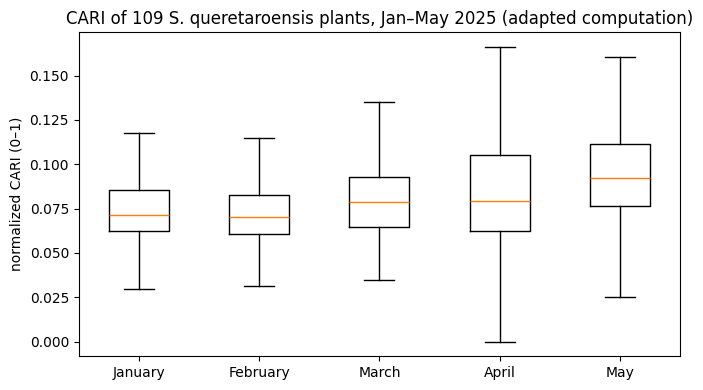

month
January      8.546
February     8.431
March        9.503
April        9.572
May         11.280
Name: CARI, dtype: float64


In [ ]:
lo, hi = cari_df["CARI"].min(), cari_df["CARI"].max()
cari_df["CARI_01"] = (cari_df["CARI"] - lo) / (hi - lo)   # display-only normalization

fig, ax = plt.subplots(figsize=(7, 4))
data = [cari_df.loc[cari_df["month"] == m, "CARI_01"] for m in [x.capitalize() for x in MONTHS]]
ax.boxplot(data, tick_labels=[x.capitalize() for x in MONTHS], showfliers=False)
ax.set_ylabel("normalized CARI (0–1)")
ax.set_title("CARI of 109 S. queretaroensis plants, Jan–May 2025 (adapted computation)")
plt.tight_layout(); plt.show()

monthly_median = cari_df.groupby("month")["CARI"].median().reindex([x.capitalize() for x in MONTHS])
print(monthly_median)

## 7. Results table and CSV export / 結果表とエクスポート

Per-plant monthly medians (3 replicates aggregated with the median), exported to CSV inside the Colab workspace.

(日本語) 3 反復を中央値で集約した植物ごとの月別 CARI 中央値を表と CSV にします。

In [ ]:
plant_median = (cari_df.groupby(["plant", "month"])["CARI"].median()
                      .unstack("month")[ [x.capitalize() for x in MONTHS] ])
display(plant_median.head(10))
plant_median.to_csv("/content/phenopaper/cari_plant_month_median.csv")
print("rows:", len(plant_median), "-> /content/phenopaper/cari_plant_month_median.csv")

month,January,February,March,April,May
plant,,,,,
A08,11.178,12.378,13.148,14.024,13.804
A09,7.824,9.308,10.656,9.464,17.480
A12,7.968,7.256,4.392,7.894,10.390
A13,9.366,11.432,11.018,12.358,16.474
A16,7.832,9.426,8.896,9.698,13.866
A17,7.880,7.094,8.806,11.248,11.668
A18,8.078,9.272,8.548,10.618,12.250
A20,6.990,7.516,7.668,12.710,10.182
B02,7.896,8.012,8.632,10.010,8.964


rows: 111 -> /content/phenopaper/cari_plant_month_median.csv


## 8. Interpretation, differences from the paper, validation record / 解釈と検証記録

**What was reproduced exactly (numerically verified):** the 2 nm cubic-spline resampling (Section 5.1.2.5) — our `CubicSpline` values match the authors' own `*_interp.mat` files for the example spectrum to within the printed tolerance, on the identical 151-point grid.

**What was adapted:** the CARI computation (Section 5.1.2.6). The paper shows a normalized 0–1 CARI but states no formula, and no author code is bundled; we used a documented formula and display-only min–max normalization. The paper's *qualitative* finding — a narrow April distribution and a notable shift in May, when most plants flower or fruit — is the expected outcome of the boxplot above; a single-example/statistical agreement with the paper's exact figure is **not** claimed.

**Known differences / limitations**
- The v1 archive holds no drone imagery, so the NDVI/ROI part of the paper is out of scope here.
- A few plant/replicate `.mat` files are absent in the archive (3268 = 5×109×3 − 67); they are skipped and counted in the output.
- MATLAB `interp1` `'spline'` and SciPy `CubicSpline` (not-a-knot) agree mathematically; remaining differences are floating-point level (see printed tolerance).

**Provenance:** dataset v1 doi:10.17632/skw8tjc82f.1 (CC BY 4.0), SHA-256 `815d33965fdcdbc2410e7dcf86fdfaa213c0420929e8aab402547dfe664d6da9`; paper doi:10.1016/j.dib.2025.112315 (open access). Author figures used as labeled source material only.

**References**
1. Rivera-Romero et al., Data in Brief 64:112315 (2025). doi:10.1016/j.dib.2025.112315
2. Multimodal_Cactaceae_Dataset_25, Mendeley Data V1. doi:10.17632/skw8tjc82f.1
3. CARI formula: Plant Phenomics 9:0063 (2023), doi:10.34133/plantphenomics.0063 (after Haboudane et al. 2002).

(日本語) 生スペクトル→2 nm スプライン補間は著者の結果と数値比較まで検証済み。CARI は定義式が本文にないため翻訳・調整版として明示し、月別分布の定性比較（5 月の変化）のみを主張しています。ドローン画像解析は v1 アーカイブに含まれないため対象外です。